In [2]:
import os, gc, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pandas.api.types import union_categoricals
from scipy import sparse
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve)
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except ImportError:          # allows the code to run as a plain script too
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

from sklearn.ensemble import RandomForestClassifier

In [3]:
MODEL_NAME = "Random Forest"
MODEL_SLUG = "random_forest"
RANDOM_STATE = 42
TRAIN_FRACTION = 0.80                 # 80 % train / 20 % test
SPLIT_MODE = "chronological"          # "chronological" (sort by Timestamp: first 80 % = train, last 20 % = test)  or  "random" (stratified)
THRESHOLDS = [0.50, 0.40, 0.30, 0.20, 0.10]
TARGET_PRECISION = 0.20               # project goal
TARGET_RECALL = 0.80                  # project goal
DEBUG_NROWS = None                    # None = ALL rows. e.g. 300_000 only for a quick smoke test
N_ESTIMATORS = 100
MAX_DEPTH = 20                        # keeps trees (and the saved file) a manageable size
MIN_SAMPLES_LEAF = 20
MAX_SAMPLES = None                    # None = every tree sees a full-size bootstrap of ALL training rows (slowest, most faithful)


USE_TABLES = {"account_behaviour": True, "graph_features": True, "temporal_features": True, "banks": True}


def find_project_root():
    """Walk upwards from the notebook's folder until we find the AML-GNN-Project root
    (the folder that contains data/processed). Works from notebooks/ or models/."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data" / "processed").is_dir():
            return cand
    raise FileNotFoundError("Could not find a folder containing data/processed. "
                            "Open the notebook from inside AML-GNN-Project or set PROJECT_ROOT manually.")

PROJECT_ROOT = find_project_root()          # e.g. PROJECT_ROOT = Path(r"C:/.../AML-GNN-Project")
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR     = PROJECT_ROOT / "models"
OUTPUTS_DIR    = PROJECT_ROOT / "outputs"
RESULTS_DIR    = PROJECT_ROOT / "results"
for d in (MODELS_DIR, OUTPUTS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

PATH_TRANSACTIONS      = DATA_PROCESSED / "transactions.csv"
PATH_TX_FEATURES       = DATA_PROCESSED / "transaction_features.csv"
PATH_ACCOUNT_BEHAVIOUR = DATA_PROCESSED / "account_behaviour.csv"
PATH_TEMPORAL          = DATA_PROCESSED / "temporal_features.csv"
PATH_GRAPH             = DATA_PROCESSED / "graph_features.csv"
PATH_BANKS             = DATA_PROCESSED / "banks.csv"
PATH_ACCOUNTS          = DATA_PROCESSED / "accounts.csv"
PATH_PATTERNS          = DATA_RAW / "LI-Small_Patterns.txt"

print("Project root :", PROJECT_ROOT)
for p in (PATH_TRANSACTIONS, PATH_TX_FEATURES, PATH_ACCOUNT_BEHAVIOUR, PATH_TEMPORAL, PATH_GRAPH, PATH_BANKS, PATH_ACCOUNTS):
    print(f"  {'OK     ' if p.exists() else 'MISSING'} {p.relative_to(PROJECT_ROOT)}")

Project root : E:\AML-GNN-Project
  OK      data\processed\transactions.csv
  OK      data\processed\transaction_features.csv
  OK      data\processed\account_behaviour.csv
  OK      data\processed\temporal_features.csv
  OK      data\processed\graph_features.csv
  OK      data\processed\banks.csv
  OK      data\processed\accounts.csv


In [4]:
# Which columns are taken from which processed table. Nothing is created - these are the columns of the files.
TX_COLS = ["Transaction ID", "Timestamp", "From Bank", "To Bank", "Amount Received", "Receiving Currency",
           "Amount Paid", "Payment Currency", "Payment Format", "Is Laundering"]
TF_COLS = ["Transaction ID", "Is Currency Same", "Transaction Hour", "Day of Week",
           "Sender Bank Country", "Receiver Bank Country", "Is Cross Border"]
AB_COLS = ["Incoming Transaction Count", "Outgoing Transaction Count", "Total Incoming Amount", "Total Outgoing Amount",
           "Average Incoming Amount", "Average Outgoing Amount", "Unique Senders", "Unique Receivers"]
GF_COLS = ["Sender In Degree", "Sender Out Degree", "Sender PageRank", "Receiver In Degree", "Receiver Out Degree", "Receiver PageRank",
           "Sender Triangle Count", "Receiver Triangle Count", "Sender Community Size", "Receiver Community Size"]
TP_COLS = ["Transactions Last 1 Hour", "Transactions Last 24 Hours", "Transactions Last 7 Days", "Amount Last 24 Hours", "Time Since Previous Transaction"]
BANK_COLS = ["Sender Transaction Count", "Receiver Transaction Count"]      # banks.csv, joined on Bank ID
# NOT used as model inputs (identifiers / text / the target): Account IDs, Bank IDs, Community IDs, Entity names, Account numbers, Country Pair.

In [5]:
t0 = time.time()
f32 = lambda cols: {c: "float32" for c in cols}

tx = pd.read_csv(PATH_TRANSACTIONS, usecols=TX_COLS, nrows=DEBUG_NROWS,
                 dtype={"Transaction ID": "int32", "From Bank": "int32", "To Bank": "int32", "Timestamp": "category",
                        "Receiving Currency": "category", "Payment Currency": "category", "Payment Format": "category", "Is Laundering": "int8"})
print(f"transactions.csv          : {tx.shape[0]:>10,} rows x {tx.shape[1]} columns")

tf = pd.read_csv(PATH_TX_FEATURES, usecols=TF_COLS + [], nrows=DEBUG_NROWS,
                 dtype={"Transaction ID": "int32", "Transaction Hour": "float32", "Day of Week": "float32", "Sender Bank Country": "category",
                        "Receiver Bank Country": "category", "Is Currency Same": "category", "Is Cross Border": "category", "Sender Account ID": "category"})
print(f"transaction_features.csv  : {tf.shape[0]:>10,} rows x {tf.shape[1]} columns")

transactions.csv          :  6,924,049 rows x 10 columns
transaction_features.csv  :  6,924,049 rows x 7 columns


In [6]:
ab = pd.read_csv(PATH_ACCOUNT_BEHAVIOUR, usecols=["Transaction ID"] + AB_COLS, dtype={"Transaction ID": "int32", **f32(AB_COLS)}, nrows=DEBUG_NROWS) if USE_TABLES["account_behaviour"] else None
gf = pd.read_csv(PATH_GRAPH, usecols=["Transaction ID"] + GF_COLS, dtype={"Transaction ID": "int32", **f32(GF_COLS)}, nrows=DEBUG_NROWS) if USE_TABLES["graph_features"] else None
tp = pd.read_csv(PATH_TEMPORAL, usecols=["Transaction ID"] + TP_COLS, dtype={"Transaction ID": "int32", **f32(TP_COLS)}, nrows=DEBUG_NROWS) if USE_TABLES["temporal_features"] else None
banks = pd.read_csv(PATH_BANKS, usecols=["Bank ID"] + BANK_COLS, dtype={"Bank ID": "int32", **f32(BANK_COLS)}) if USE_TABLES["banks"] else None
for nm, t in [("account_behaviour.csv", ab), ("graph_features.csv", gf), ("temporal_features.csv", tp), ("banks.csv", banks)]:
    print(f"{nm:<26}: " + (f"{t.shape[0]:>10,} rows x {t.shape[1]} columns" if t is not None else "not used (switched off in USE_TABLES)"))
print(f"All tables loaded in {time.time() - t0:.1f}s")

account_behaviour.csv     :  6,924,049 rows x 9 columns
graph_features.csv        :  6,924,049 rows x 11 columns
temporal_features.csv     :  6,924,049 rows x 6 columns
banks.csv                 :     41,815 rows x 3 columns
All tables loaded in 27.6s


In [7]:
# Every transaction-level table is joined to transactions.csv on Transaction ID (one row per transaction, nothing duplicated).
n_tx = len(tx)
for nm, t in [("transaction_features", tf), ("account_behaviour", ab), ("graph_features", gf), ("temporal_features", tp)]:
    if t is None:
        continue
    assert t["Transaction ID"].is_unique, f"{nm}: Transaction ID is not unique"
    tx = tx.merge(t, on="Transaction ID", how="left", validate="one_to_one")
    assert len(tx) == n_tx, f"join with {nm} changed the row count"
    print(f"+ {nm:<22} -> {tx.shape[0]:,} rows x {tx.shape[1]} columns")
    del t
gc.collect()

# banks.csv is a Bank-level table: join once for the sender's bank and once for the receiver's bank (Bank ID is unique in banks.csv).
if banks is not None:
    for side, key in (("Sender", "From Bank"), ("Receiver", "To Bank")):
        b = banks.rename(columns={"Bank ID": key, "Sender Transaction Count": f"{side} Bank - Sender Txn Count",
                                  "Receiver Transaction Count": f"{side} Bank - Receiver Txn Count"})
        tx = tx.merge(b, on=key, how="left", validate="many_to_one")
        assert len(tx) == n_tx
    print(f"+ banks (sender & receiver) -> {tx.shape[0]:,} rows x {tx.shape[1]} columns")
del tf, ab, gf, tp, banks
gc.collect()
print(f"\nMerged table: {tx.shape[0]:,} rows (transactions loaded: {n_tx:,})  | memory {tx.memory_usage(deep=True).sum() / 1e9:.2f} GB")

+ transaction_features   -> 6,924,049 rows x 16 columns
+ account_behaviour      -> 6,924,049 rows x 24 columns
+ graph_features         -> 6,924,049 rows x 34 columns
+ temporal_features      -> 6,924,049 rows x 39 columns
+ banks (sender & receiver) -> 6,924,049 rows x 43 columns

Merged table: 6,924,049 rows (transactions loaded: 6,924,049)  | memory 1.07 GB


In [8]:
# ---- Timestamp -> numbers (only used to order the data in time; it is not a model input) ----
def parse_timestamp_column(col):
    col = col.astype("category")
    cats = pd.Series(col.cat.categories.astype(str))
    for fmt in ["%d-%m-%Y %H:%M", "%Y/%m/%d %H:%M", "%Y-%m-%d %H:%M", "%d/%m/%Y %H:%M", "%m/%d/%Y %H:%M"]:
        parsed = pd.to_datetime(cats, format=fmt, errors="coerce")
        if parsed.notna().mean() > 0.999:
            print("Timestamp format:", fmt)
            break
    else:
        raise ValueError("Unknown Timestamp format")
    secs = (parsed - pd.Timestamp("1970-01-01")).dt.total_seconds().to_numpy()
    return np.append(secs, np.nan)[col.cat.codes.to_numpy()]

ts_abs = parse_timestamp_column(tx["Timestamp"])
bad = np.isnan(ts_abs)
print(f"Rows with an unreadable Timestamp (dropped): {int(bad.sum()):,}")
tx = tx.loc[~bad].drop(columns=["Timestamp"]).reset_index(drop=True)
tx["ts_abs"] = ts_abs[~bad].astype(np.int64)
del ts_abs, bad

# ---- TRUE/FALSE text columns -> 1/0 ----
def binary_from_category(s):
    s = s.astype("category")
    truthy = {"TRUE", "1", "1.0", "YES", "T", "Y"}
    lookup = np.array([1 if str(c).strip().upper() in truthy else 0 for c in s.cat.categories] + [-1], dtype=np.float32)
    out = lookup[s.cat.codes.to_numpy()]
    out[s.cat.codes.to_numpy() < 0] = np.nan
    return out
for c in ["Is Currency Same", "Is Cross Border"]:
    tx[c] = binary_from_category(tx[c])

# ---- chronological order (needed for the time-based split) ----
tx = tx.sort_values(["ts_abs", "Transaction ID"], kind="stable").reset_index(drop=True)
ts_abs = tx["ts_abs"].to_numpy()
print("Data spans:", pd.to_datetime(ts_abs[0], unit="s"), "->", pd.to_datetime(ts_abs[-1], unit="s"))

# ---- Transaction Hour / Day of Week: use the file's values; only if a value is blank, take it from this row's Timestamp ----
hour_ts = ((ts_abs // 3600) % 24).astype(np.float32)
dow_ts = (((ts_abs // 86400) + 3) % 7).astype(np.float32)          # 0 = Monday
for col, derived in (("Transaction Hour", hour_ts), ("Day of Week", dow_ts)):
    n_blank = int(tx[col].isna().sum())
    print(f"{col}: {n_blank:,} blank values in the file ({n_blank / len(tx):.1%})")
    if n_blank:
        print(f"   -> blanks filled from the transaction's own Timestamp")
        tx[col] = tx[col].fillna(pd.Series(derived))
del hour_ts, dow_ts
gc.collect()

# ---- missing values per column ----
miss = tx.isna().sum()
print("\nColumns with missing values (these are filled with -1 in the model matrix):")
print(miss[miss > 0].to_string() if (miss > 0).any() else "none")

Timestamp format: %Y/%m/%d %H:%M
Rows with an unreadable Timestamp (dropped): 0
Data spans: 2022-09-01 00:00:00 -> 2022-09-17 15:28:00
Transaction Hour: 6,924,049 blank values in the file (100.0%)
   -> blanks filled from the transaction's own Timestamp
Day of Week: 6,924,049 blank values in the file (100.0%)
   -> blanks filled from the transaction's own Timestamp

Columns with missing values (these are filled with -1 in the model matrix):
Time Since Previous Transaction    681283


In [9]:
day = ts_abs // 86400
u, inv, cnt = np.unique(day, return_inverse=True, return_counts=True)
pos = np.bincount(inv.ravel(), weights=tx["Is Laundering"].to_numpy(), minlength=len(u)).astype(int)
daily = pd.DataFrame({"Date": pd.to_datetime(u * 86400, unit="s").date, "Rows": cnt, "Laundering": pos})
daily["Laundering %"] = 100 * daily["Laundering"] / daily["Rows"]
print("Rows and laundering cases per day (information only - nothing is removed):")
with pd.option_context("display.float_format", lambda v: f"{v:,.3f}"):
    display(daily)

Rows and laundering cases per day (information only - nothing is removed):


,Date,Rows,Laundering,Laundering %
0,2022-09-01,1524807,310,0.020
1,2022-09-02,1027758,350,0.034
2,2022-09-03,283326,292,0.103
3,2022-09-04,282476,291,0.103
4,2022-09-05,657397,370,0.056
5,2022-09-06,657170,380,0.058
6,2022-09-07,658504,368,0.056
7,2022-09-08,657938,402,0.061
8,2022-09-09,891573,367,0.041
9,2022-09-10,282877,301,0.106


In [10]:
y = tx["Is Laundering"].to_numpy(np.int8)
tx_ids = tx["Transaction ID"].to_numpy(np.int64)
n = len(y)
cut = int(TRAIN_FRACTION * n)

if SPLIT_MODE == "chronological":
    train_idx, test_idx = np.arange(0, cut), np.arange(cut, n)      # data is already sorted by time: past = train, future = test
else:
    train_idx, test_idx = train_test_split(np.arange(n), test_size=1 - TRAIN_FRACTION, stratify=y, random_state=RANDOM_STATE)
    train_idx, test_idx = np.sort(train_idx), np.sort(test_idx)

if y[train_idx].sum() == 0 or y[test_idx].sum() == 0:
    print("!" * 80)
    print("WARNING: the chronological split leaves a set without laundering examples -> falling back to a stratified random 80/20 split.")
    print("!" * 80)
    SPLIT_MODE = "random (fallback)"
    train_idx, test_idx = train_test_split(np.arange(n), test_size=1 - TRAIN_FRACTION, stratify=y, random_state=RANDOM_STATE)
    train_idx, test_idx = np.sort(train_idx), np.sort(test_idx)

print(f"Split mode: {SPLIT_MODE}")
print(f"Train rows: {len(train_idx):,} | Test rows: {len(test_idx):,}   (ALL {n:,} rows are used - nothing sampled or removed)")
print(f"Train laundering: {int(y[train_idx].sum()):,} | Train normal: {int((y[train_idx] == 0).sum()):,} | Train laundering %: {100 * y[train_idx].mean():.4f}")
print(f"Test  laundering: {int(y[test_idx].sum()):,} | Test  normal: {int((y[test_idx] == 0).sum()):,} | Test  laundering %: {100 * y[test_idx].mean():.4f}")
if SPLIT_MODE == "chronological":
    print("Train period:", pd.to_datetime(ts_abs[train_idx[0]], unit="s"), "->", pd.to_datetime(ts_abs[train_idx[-1]], unit="s"))
    print("Test  period:", pd.to_datetime(ts_abs[test_idx[0]], unit="s"), "->", pd.to_datetime(ts_abs[test_idx[-1]], unit="s"))

Split mode: chronological
Train rows: 5,539,239 | Test rows: 1,384,810   (ALL 6,924,049 rows are used - nothing sampled or removed)
Train laundering: 2,640 | Train normal: 5,536,599 | Train laundering %: 0.0477
Test  laundering: 925 | Test  normal: 1,383,885 | Test  laundering %: 0.0668
Train period: 2022-09-01 00:00:00 -> 2022-09-08 16:06:00
Test  period: 2022-09-08 16:06:00 -> 2022-09-17 15:28:00


In [11]:
CAT_COLS = ["Receiving Currency", "Payment Currency", "Payment Format", "Sender Bank Country", "Receiver Bank Country"]
NUMERIC_COLS = ["Amount Received", "Amount Paid", "Is Currency Same", "Is Cross Border", "Transaction Hour", "Day of Week"]
for cols, tbl in [(AB_COLS, "account_behaviour"), (GF_COLS, "graph_features"), (TP_COLS, "temporal_features")]:
    if USE_TABLES[tbl]:
        NUMERIC_COLS += cols
if USE_TABLES["banks"]:
    NUMERIC_COLS += [c for c in tx.columns if c.endswith("Txn Count") and "Bank" in c]
print(f"{len(NUMERIC_COLS)} numeric columns taken straight from the tables:"); print(NUMERIC_COLS)

# one-hot levels are learned from the TRAIN rows only
cat_levels = {c: sorted(tx[c].iloc[train_idx].dropna().astype(str).unique()) for c in CAT_COLS}

def build_X(idx):
    part = tx.iloc[idx]
    blocks = [part[NUMERIC_COLS].astype(np.float32).fillna(-1).reset_index(drop=True)]
    for c in CAT_COLS:
        s = part[c].astype(str).astype("category").cat.set_categories(cat_levels[c])
        blocks.append(pd.get_dummies(s, prefix=c, dtype=np.float32).reset_index(drop=True))
    X = pd.concat(blocks, axis=1)
    X.columns = [re.sub(r"[\[\]<>]", "_", str(col)) for col in X.columns]
    return X

X_train, y_train = build_X(train_idx), y[train_idx]
X_test, y_test = build_X(test_idx), y[test_idx]
print(f"X_train {X_train.shape} | X_test {X_test.shape}")
assert not np.isnan(X_train.to_numpy()).any() and not np.isnan(X_test.to_numpy()).any()
feature_names = list(X_train.columns)
del tx
gc.collect()

33 numeric columns taken straight from the tables:
['Amount Received', 'Amount Paid', 'Is Currency Same', 'Is Cross Border', 'Transaction Hour', 'Day of Week', 'Incoming Transaction Count', 'Outgoing Transaction Count', 'Total Incoming Amount', 'Total Outgoing Amount', 'Average Incoming Amount', 'Average Outgoing Amount', 'Unique Senders', 'Unique Receivers', 'Sender In Degree', 'Sender Out Degree', 'Sender PageRank', 'Receiver In Degree', 'Receiver Out Degree', 'Receiver PageRank', 'Sender Triangle Count', 'Receiver Triangle Count', 'Sender Community Size', 'Receiver Community Size', 'Transactions Last 1 Hour', 'Transactions Last 24 Hours', 'Transactions Last 7 Days', 'Amount Last 24 Hours', 'Time Since Previous Transaction', 'Sender Bank - Sender Txn Count', 'Sender Bank - Receiver Txn Count', 'Receiver Bank - Sender Txn Count', 'Receiver Bank - Receiver Txn Count']
X_train (5539239, 94) | X_test (1384810, 94)


0

In [12]:
def evaluate_scores(y_true, score, threshold=0.50):
    """Binary metrics at a threshold + ranking metrics (ROC-AUC, PR-AUC) that do not depend on the threshold."""
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    both = len(np.unique(y_true)) == 2
    return {
        "Threshold": float(threshold),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1-Score": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, score) if both else np.nan,
        "PR-AUC": average_precision_score(y_true, score) if both else np.nan,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def best_f1_threshold(y_true, score):
    """Threshold maximising F1 - to be computed on VALIDATION data only (never on the test set)."""
    p, r, t = precision_recall_curve(y_true, score)
    f1 = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
    return float(t[int(np.argmax(f1))]) if len(t) else 0.5


def save_confusion_matrix(y_true, pred, path, title):
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({norm[i, j]:.1%} of row)", ha="center", va="center",
                    color="white" if norm[i, j] > 0.5 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Normal", "Pred Laundering"]); ax.set_yticklabels(["Actual Normal", "Actual Laundering"])
    ax.set_title(title); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_roc_curve(y_true, score, path, title):
    fpr, tpr, _ = roc_curve(y_true, score)
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_true, score):.4f}")
    ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guess")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(title); ax.legend(); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_pr_curve(y_true, score, path, title):
    p, r, _ = precision_recall_curve(y_true, score)
    prevalence = float(np.mean(y_true))
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    ax.plot(r, p, label=f"PR-AUC (AP) = {average_precision_score(y_true, score):.4f}")
    ax.axhline(prevalence, ls="--", color="grey", label=f"No-skill baseline = {prevalence:.5f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title(title); ax.legend()
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_risk_distribution(y_true, score, path, title, threshold=0.50):
    y_true = np.asarray(y_true)
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    bins = np.linspace(0, 1, 51)
    ax.hist(score[y_true == 0], bins=bins, alpha=0.65, label="Actual normal", color="tab:blue")
    ax.hist(score[y_true == 1], bins=bins, alpha=0.75, label="Actual laundering", color="tab:red")
    ax.axvline(threshold, color="black", ls="--", label=f"Threshold = {threshold:.2f}")
    ax.set_yscale("log"); ax.set_xlabel("AML Risk Score  =  P(Is Laundering = 1)"); ax.set_ylabel("Number of transactions (log scale)")
    ax.set_title(title); ax.legend(); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()


def save_feature_importance(names, values, path, title, top=25):
    imp = pd.Series(values, index=names).sort_values(ascending=False).head(top)[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.33 * len(imp) + 1.5))
    ax.barh(imp.index, imp.values, color="tab:green")
    ax.set_title(title); ax.set_xlabel("Importance"); fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()
    return imp[::-1]


def predict_in_chunks(model, X, chunk=200_000):
    """predict_proba(...)[:, 1] in chunks to keep memory low."""
    out = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), chunk):
        out[i:i + chunk] = model.predict_proba(X.iloc[i:i + chunk])[:, 1]
    return out



# ---------- threshold study (target: precision >= 20 %, recall >= 80 %) ----------
# 0.50 / 0.40 / 0.30 / 0.20 / 0.10 were requested; the other values are extras (RF / LR scores can sit far from 0.5).
SWEEP_THRESHOLDS = [0.90, 0.70, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05, 0.02]


def threshold_sweep(y_true, score, thresholds=SWEEP_THRESHOLDS):
    rows = []
    for t in thresholds:
        m = evaluate_scores(y_true, score, t)
        rows.append({"Threshold": t, "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "TN": m["TN"],
                     "Precision": m["Precision"], "Recall": m["Recall"], "F1-Score": m["F1-Score"],
                     "Flagged": m["TP"] + m["FP"],
                     f"Meets P>={TARGET_PRECISION:.0%} & R>={TARGET_RECALL:.0%}": bool(m["Precision"] >= TARGET_PRECISION and m["Recall"] >= TARGET_RECALL)})
    return pd.DataFrame(rows)


def pick_threshold_for_recall(y_val, s_val, min_recall=None):
    """Highest threshold whose VALIDATION recall is still >= min_recall (= best precision that keeps the recall target).
    Returns None if no threshold reaches the recall target on validation."""
    min_recall = TARGET_RECALL if min_recall is None else min_recall
    p, r, t = precision_recall_curve(y_val, s_val)
    ok = np.where(r[:-1] >= min_recall)[0]
    return float(t[ok[-1]]) if len(ok) else None


def subset_metrics(y_true, score, masks, threshold):
    rows = []
    for name, m in masks.items():
        if m.sum() == 0:
            continue
        rows.append({"Subset": name, "Rows": int(m.sum()), "Laundering": int(y_true[m].sum()), **evaluate_scores(y_true[m], score[m], threshold)})
    return pd.DataFrame(rows)


def save_threshold_tradeoff(y_true, score, path, title):
    p, r, t = precision_recall_curve(y_true, score)
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(t, p[:-1], label="Precision"); ax.plot(t, r[:-1], label="Recall")
    ax.axhline(TARGET_PRECISION, ls="--", color="tab:blue", alpha=0.5, label=f"Target precision {TARGET_PRECISION:.0%}")
    ax.axhline(TARGET_RECALL, ls="--", color="tab:orange", alpha=0.5, label=f"Target recall {TARGET_RECALL:.0%}")
    ax.set_xlabel("Threshold on AML Risk Score"); ax.set_ylabel("Precision / Recall"); ax.set_title(title); ax.legend()
    fig.tight_layout(); fig.savefig(path, dpi=150); plt.show()

all_metrics = []     # every metrics row is collected here and saved at the end

In [13]:
print(f"Training on ALL {len(X_train):,} training rows | laundering: {int(y_train.sum()):,} | normal: {int((y_train == 0).sum()):,}")
model = RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, min_samples_leaf=MIN_SAMPLES_LEAF, max_samples=MAX_SAMPLES,
                               max_features="sqrt", class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)
t0 = time.time(); model.fit(X_train, y_train)
print(f"Training finished in {(time.time() - t0) / 60:.1f} min")

Training on ALL 5,539,239 training rows | laundering: 2,640 | normal: 5,536,599
Training finished in 10.6 min


In [14]:
score_test = predict_in_chunks(model, X_test)            # AML Risk Score = P(Is Laundering = 1)
pred_table = pd.DataFrame({"Transaction ID": tx_ids[test_idx], "Actual Is Laundering": y_test.astype(int),
                           "AML Risk Score": np.round(score_test, 6), "Predicted Label": (score_test >= 0.50).astype(int)})
print("First 10 test predictions:"); display(pred_table.head(10))
print("Top 10 highest AML Risk Scores:"); display(pred_table.sort_values("AML Risk Score", ascending=False).head(10))
print(f"Average risk score {score_test.mean():.4f} | highest {score_test.max():.4f}")

First 10 test predictions:


,Transaction ID,Actual Is Laundering,AML Risk Score,Predicted Label
0,5544005,0,0.000000,0
1,5544098,0,0.000000,0
2,5544111,0,0.000000,0
3,5544124,0,0.000000,0
4,5544135,0,0.000000,0
5,5544152,0,0.026670,0
6,5544161,0,0.000000,0
7,5544184,0,0.192146,0
8,5544197,0,0.010737,0
9,5544206,0,0.508948,1


Top 10 highest AML Risk Scores:


,Transaction ID,Actual Is Laundering,AML Risk Score,Predicted Label
976798,3841204,1,0.994795,1
95354,5635788,0,0.987319,1
918445,6445874,0,0.986159,1
61338,5591969,0,0.985599,1
1198518,6740484,0,0.985419,1
6773,5543992,0,0.983944,1
1582,5537737,0,0.983824,1
544253,6095295,0,0.983303,1
492174,6025955,0,0.978253,1
2582,5540525,0,0.977871,1


Average risk score 0.0542 | highest 0.9948


In [15]:
# ============================================================================================
# THRESHOLD STUDY  (cell 1 of 4): run thresholds 0.50, 0.40, 0.30, 0.20, 0.10 one after another
# Rule applied each time:  AML Risk Score >= threshold  ->  predicted laundering (1), else normal (0)
# ============================================================================================
THRESHOLDS = [0.50, 0.40, 0.30, 0.20, 0.10]
y_test = y[test_idx]                       # true labels of the (untouched) test set
threshold_rows = []

for thr in THRESHOLDS:
    pred = (score_test >= thr).astype(int)
    m = evaluate_scores(y_test, score_test, thr)           # Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, TN, FP, FN, TP
    m["Flagged"] = m["TP"] + m["FP"]
    m["Flagged % of test"] = 100 * m["Flagged"] / len(y_test)
    threshold_rows.append(m)

    print("=" * 78)
    print(f"{MODEL_NAME.upper()}  |  THRESHOLD = {thr:.2f}")
    print("=" * 78)
    print(f"TP (laundering caught)  : {m['TP']:,}")
    print(f"FP (normal flagged)     : {m['FP']:,}")
    print(f"FN (laundering missed)  : {m['FN']:,}")
    print(f"TN (normal passed)      : {m['TN']:,}")
    print(f"Transactions flagged    : {m['Flagged']:,}  ({m['Flagged % of test']:.2f}% of the test set)")
    print(f"Accuracy {m['Accuracy']:.4f} | Precision {m['Precision']:.4f} | Recall {m['Recall']:.4f} | "
          f"F1 {m['F1-Score']:.4f} | ROC-AUC {m['ROC-AUC']:.4f} | PR-AUC {m['PR-AUC']:.4f}")
    print(classification_report(y_test, pred, target_names=["Normal (0)", "Laundering (1)"], digits=4, zero_division=0))

RANDOM FOREST  |  THRESHOLD = 0.50
TP (laundering caught)  : 616
FP (normal flagged)     : 45,124
FN (laundering missed)  : 309
TN (normal passed)      : 1,338,761
Transactions flagged    : 45,740  (3.30% of the test set)
Accuracy 0.9672 | Precision 0.0135 | Recall 0.6659 | F1 0.0264 | ROC-AUC 0.9688 | PR-AUC 0.0454
                precision    recall  f1-score   support

    Normal (0)     0.9998    0.9674    0.9833   1383885
Laundering (1)     0.0135    0.6659    0.0264       925

      accuracy                         0.9672   1384810
     macro avg     0.5066    0.8167    0.5049   1384810
  weighted avg     0.9991    0.9672    0.9827   1384810

RANDOM FOREST  |  THRESHOLD = 0.40
TP (laundering caught)  : 707
FP (normal flagged)     : 81,897
FN (laundering missed)  : 218
TN (normal passed)      : 1,301,988
Transactions flagged    : 82,604  (5.97% of the test set)
Accuracy 0.9407 | Precision 0.0086 | Recall 0.7643 | F1 0.0169 | ROC-AUC 0.9688 | PR-AUC 0.0454
                precision

In [16]:
# ============================================================================================
# THRESHOLD STUDY (cell 2 of 4): comparison table
# ============================================================================================
thr_df = pd.DataFrame(threshold_rows)[["Threshold", "TP", "FP", "FN", "TN", "Flagged", "Flagged % of test",
                                       "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]]
thr_df[f"Recall >= {TARGET_RECALL:.0%}?"] = thr_df["Recall"] >= TARGET_RECALL
thr_df[f"Precision >= {TARGET_PRECISION:.0%}?"] = thr_df["Precision"] >= TARGET_PRECISION
thr_df["Meets BOTH targets?"] = thr_df.iloc[:, -1] & thr_df.iloc[:, -2]

display(thr_df.set_index("Threshold"))
thr_df.to_csv(RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.csv", index=False)
print("Saved:", RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.csv")
print("\nNOTE: ROC-AUC and PR-AUC are IDENTICAL for every threshold - they measure how well the scores RANK transactions,")
print("so changing the threshold cannot change them. Only TP/FP/FN/TN, Precision, Recall, F1 and Accuracy move.")

,TP,FP,FN,TN,Flagged,Flagged % of test,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Recall >= 80%?,Precision >= 20%?,Meets BOTH targets?
Threshold,,,,,,,,,,,,,,,
0.500000,616,45124,309,1338761,45740,3.302980,0.967192,0.013467,0.665946,0.026401,0.968773,0.045423,False,False,False
0.400000,707,81897,218,1301988,82604,5.965006,0.940703,0.008559,0.764324,0.016928,0.968773,0.045423,False,False,False
0.300000,817,117813,108,1266072,118630,8.566518,0.914847,0.006887,0.883243,0.013667,0.968773,0.045423,True,False,False
0.200000,872,149341,53,1234544,150213,10.847192,0.892119,0.005805,0.942703,0.011539,0.968773,0.045423,True,False,False
0.100000,906,174660,19,1209225,175566,12.677985,0.873861,0.005160,0.979459,0.010267,0.968773,0.045423,True,False,False


Saved: E:\AML-GNN-Project\results\random_forest_threshold_comparison.csv

NOTE: ROC-AUC and PR-AUC are IDENTICAL for every threshold - they measure how well the scores RANK transactions,
so changing the threshold cannot change them. Only TP/FP/FN/TN, Precision, Recall, F1 and Accuracy move.


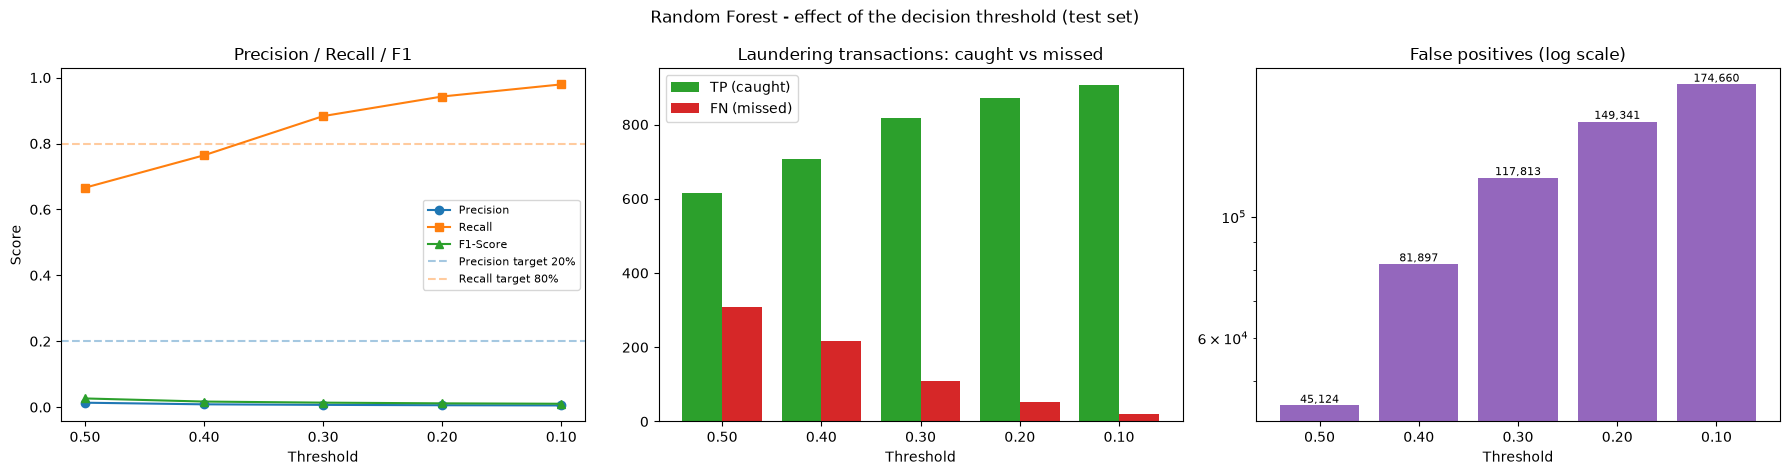

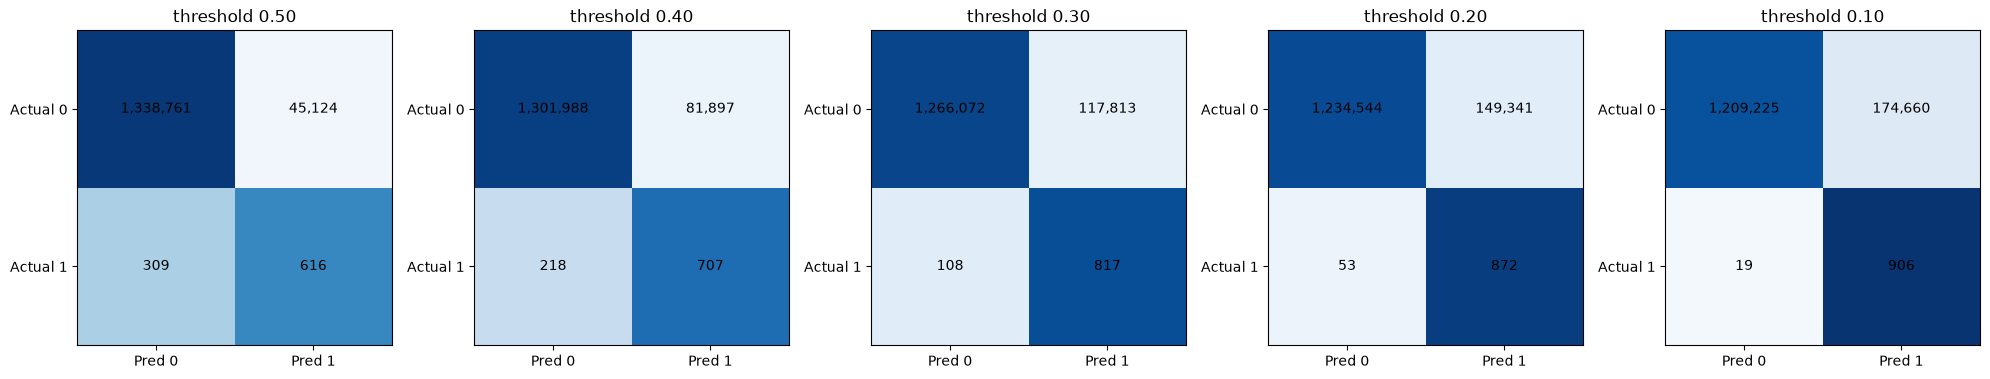

In [17]:
# ============================================================================================
# THRESHOLD STUDY (cell 3 of 4): charts comparing the five thresholds
# ============================================================================================
x = np.arange(len(thr_df)); labels = [f"{t:.2f}" for t in thr_df["Threshold"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
# (a) precision / recall / F1 against threshold
for col, mk in [("Precision", "o"), ("Recall", "s"), ("F1-Score", "^")]:
    axes[0].plot(labels, thr_df[col], marker=mk, label=col)
axes[0].axhline(TARGET_PRECISION, ls="--", color="tab:blue", alpha=0.4, label=f"Precision target {TARGET_PRECISION:.0%}")
axes[0].axhline(TARGET_RECALL, ls="--", color="tab:orange", alpha=0.4, label=f"Recall target {TARGET_RECALL:.0%}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score"); axes[0].set_title("Precision / Recall / F1"); axes[0].legend(fontsize=8)
# (b) laundering caught vs missed
axes[1].bar(x - 0.2, thr_df["TP"], 0.4, label="TP (caught)", color="tab:green")
axes[1].bar(x + 0.2, thr_df["FN"], 0.4, label="FN (missed)", color="tab:red")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels); axes[1].set_xlabel("Threshold"); axes[1].set_title("Laundering transactions: caught vs missed"); axes[1].legend()
# (c) cost of the extra recall: false positives
axes[2].bar(x, thr_df["FP"], color="tab:purple")
axes[2].set_yscale("log"); axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
axes[2].set_xlabel("Threshold"); axes[2].set_title("False positives (log scale)")
for i, v in enumerate(thr_df["FP"]):
    axes[2].text(i, max(v, 1), f"{v:,}", ha="center", va="bottom", fontsize=8)
fig.suptitle(f"{MODEL_NAME} - effect of the decision threshold (test set)")
fig.tight_layout(); fig.savefig(RESULTS_DIR / f"{MODEL_SLUG}_threshold_comparison.png", dpi=150); plt.show()

# confusion matrices side by side
fig, axes = plt.subplots(1, len(thr_df), figsize=(4 * len(thr_df), 3.8))
for ax, (_, r) in zip(axes, thr_df.iterrows()):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]], dtype=float)
    ax.imshow(cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None), cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{int(cm[i, j]):,}", ha="center", va="center", fontsize=10, color="black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"]); ax.set_yticklabels(["Actual 0", "Actual 1"])
    ax.set_title(f"threshold {r['Threshold']:.2f}")
fig.tight_layout(); fig.savefig(RESULTS_DIR / f"{MODEL_SLUG}_threshold_confusion_matrices.png", dpi=150); plt.show()

In [18]:
best_f1 = thr_df.loc[thr_df["F1-Score"].idxmax()]
print(f"Best F1 among the five thresholds : {best_f1['Threshold']:.2f}  (F1 {best_f1['F1-Score']:.4f}, precision {best_f1['Precision']:.4f}, recall {best_f1['Recall']:.4f})")
rec_ok = thr_df[thr_df["Recall"] >= TARGET_RECALL]
if len(rec_ok):
    hp = rec_ok.loc[rec_ok["Precision"].idxmax()]
    print(f"Recall >= {TARGET_RECALL:.0%} is reached at thresholds {list(rec_ok['Threshold'])}; best precision there: {hp['Precision']:.4f} at {hp['Threshold']:.2f}")
else:
    print(f"No threshold reaches recall >= {TARGET_RECALL:.0%} (best {thr_df['Recall'].max():.4f}).")
both = thr_df[thr_df["Meets BOTH targets?"]]
print(f"\nTARGET (precision >= {TARGET_PRECISION:.0%} AND recall >= {TARGET_RECALL:.0%}): " + (f"MET at {list(both['Threshold'])}" if len(both) else "NOT met at any of the five thresholds"))
print("The threshold only trades precision against recall; ROC-AUC / PR-AUC (ranking quality) do not change with it.")
print("These numbers are computed on the test set for description. A final operating threshold should be chosen on separate validation data.")

Best F1 among the five thresholds : 0.50  (F1 0.0264, precision 0.0135, recall 0.6659)
Recall >= 80% is reached at thresholds [0.3, 0.2, 0.1]; best precision there: 0.0069 at 0.30

TARGET (precision >= 20% AND recall >= 80%): NOT met at any of the five thresholds
The threshold only trades precision against recall; ROC-AUC / PR-AUC (ranking quality) do not change with it.
These numbers are computed on the test set for description. A final operating threshold should be chosen on separate validation data.


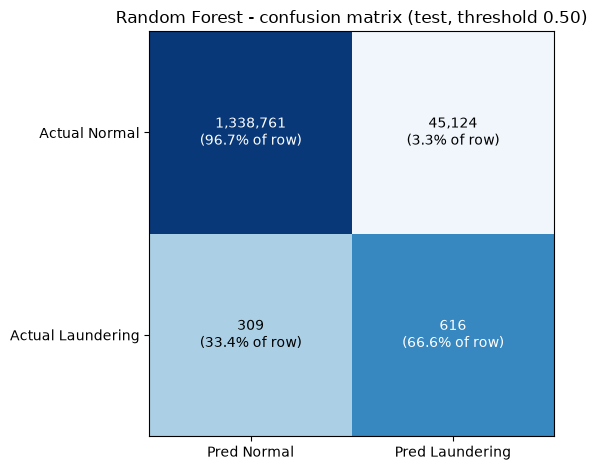

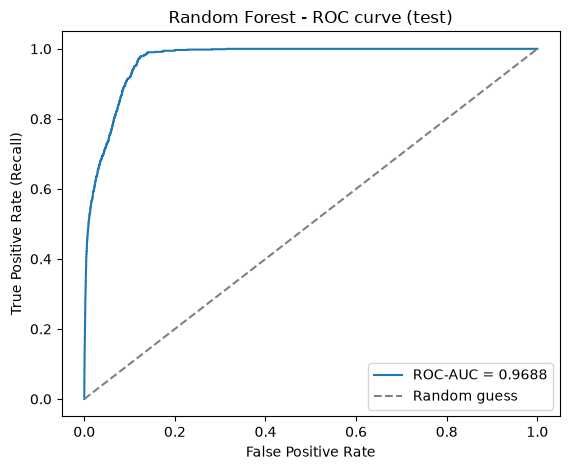

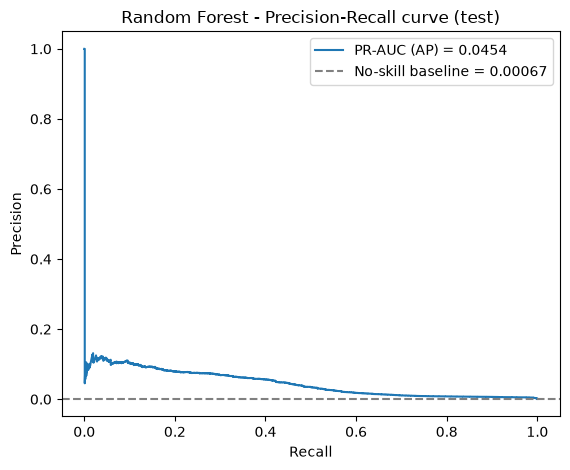

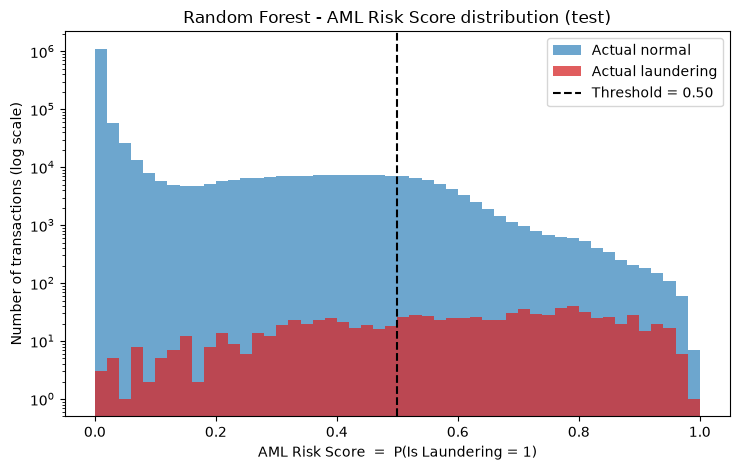

In [19]:
pred05 = (score_test >= 0.50).astype(int)
save_confusion_matrix(y_test, pred05, RESULTS_DIR / f"{MODEL_SLUG}_confusion_matrix.png", f"{MODEL_NAME} - confusion matrix (test, threshold 0.50)")
save_roc_curve(y_test, score_test, RESULTS_DIR / f"{MODEL_SLUG}_roc_curve.png", f"{MODEL_NAME} - ROC curve (test)")
save_pr_curve(y_test, score_test, RESULTS_DIR / f"{MODEL_SLUG}_pr_curve.png", f"{MODEL_NAME} - Precision-Recall curve (test)")
save_risk_distribution(y_test, score_test, RESULTS_DIR / f"{MODEL_SLUG}_risk_distribution.png", f"{MODEL_NAME} - AML Risk Score distribution (test)", 0.50)

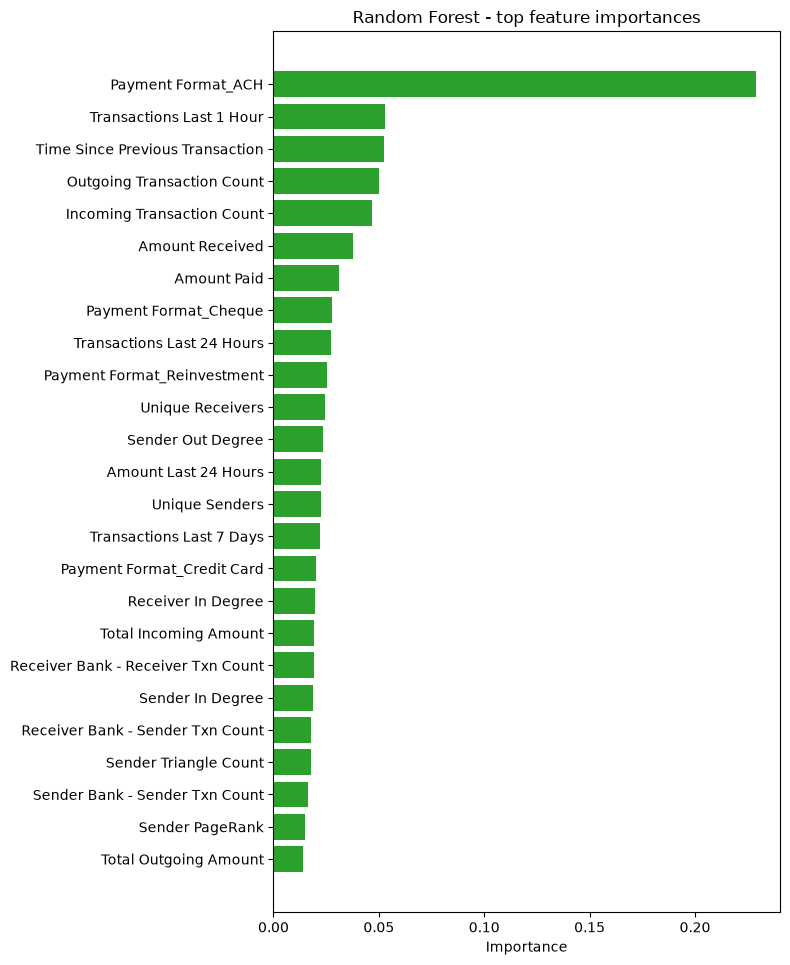

,Importance
Payment Format_ACH,0.228882
Transactions Last 1 Hour,0.052927
Time Since Previous Transaction,0.052452
Outgoing Transaction Count,0.050073
Incoming Transaction Count,0.046855
Amount Received,0.037855
Amount Paid,0.030902
Payment Format_Cheque,0.027639
Transactions Last 24 Hours,0.027260
Payment Format_Reinvestment,0.025259


In [20]:
top = save_feature_importance(feature_names, model.feature_importances_, RESULTS_DIR / f"{MODEL_SLUG}_feature_importance.png", f"{MODEL_NAME} - top feature importances")
display(top.head(15).to_frame("Importance"))

In [21]:
MODEL_PATH = MODELS_DIR / "random_forest.pkl"
joblib.dump(model, MODEL_PATH, compress=3)
joblib.dump({"feature_columns": feature_names, "cat_levels": cat_levels, "numeric_columns": NUMERIC_COLS}, MODELS_DIR / f"{MODEL_SLUG}_preprocessing.pkl")
print("Model saved to:", MODEL_PATH)

# predictions: one row per test transaction, with the label at EVERY threshold
PRED_PATH = OUTPUTS_DIR / f"{MODEL_SLUG}_predictions.csv"
out = pred_table.copy()
for t in THRESHOLDS:
    out[f"Predicted Label @{t:.2f}"] = (score_test >= t).astype(int)
out.to_csv(PRED_PATH, index=False)

# metrics: one row per threshold
METRICS_PATH = RESULTS_DIR / f"{MODEL_SLUG}_metrics.csv"
metrics_df = thr_df.copy()
metrics_df.insert(0, "Model", MODEL_NAME)
metrics_df["Train Rows"] = len(train_idx); metrics_df["Test Rows"] = len(test_idx); metrics_df["Split Mode"] = SPLIT_MODE
metrics_df.to_csv(METRICS_PATH, index=False)
print("Predictions saved to:", PRED_PATH)
print("Metrics saved to    :", METRICS_PATH)

Model saved to: E:\AML-GNN-Project\models\random_forest.pkl
Predictions saved to: E:\AML-GNN-Project\outputs\random_forest_predictions.csv
Metrics saved to    : E:\AML-GNN-Project\results\random_forest_metrics.csv


In [22]:
# LI-Small_Patterns.txt is NOT a one-row-per-transaction CSV. It is a separate pattern-analysis / validation resource.
# We only inspect it here (count the pattern types). We deliberately do NOT merge it into the feature matrix and
# we do NOT invent transaction-level pattern labels.
if PATH_PATTERNS.exists():
    begin_re = re.compile(r"BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Za-z0-9\-_ ]+?)\s*(?::|$)", re.I)
    pattern_counts, preview, n_lines = {}, [], 0
    with open(PATH_PATTERNS, "r", errors="ignore") as fh:
        for line in fh:
            n_lines += 1
            if len(preview) < 12:
                preview.append(line.rstrip())
            m = begin_re.search(line)
            if m:
                k = m.group(1).strip().upper()
                pattern_counts[k] = pattern_counts.get(k, 0) + 1
    print(f"Patterns file: {n_lines:,} lines")
    print("First lines:"); print("\n".join("   " + p for p in preview))
    if pattern_counts:
        print("\nLaundering-attempt blocks per pattern type:")
        display(pd.Series(pattern_counts, name="Attempts").sort_values(ascending=False).to_frame())
    else:
        print("No 'BEGIN LAUNDERING ATTEMPT' headers recognised - inspect the file format manually.")
else:
    print("Patterns file not found - skipping (it is not required for training).")

Patterns file: 1,374 lines
First lines:
   BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 3-degree Fan-In
   2022/09/01 02:38,001812,80279F810,0110,8000A94C0,10154.74,Australian Dollar,10154.74,Australian Dollar,ACH,1
   2022/09/02 14:36,022595,80279F8B0,0110,8000A94C0,5326.79,Australian Dollar,5326.79,Australian Dollar,ACH,1
   2022/09/03 14:09,001120,800E36A50,0110,8000A94C0,4634.81,Australian Dollar,4634.81,Australian Dollar,ACH,1
   END LAUNDERING ATTEMPT - FAN-IN
   
   BEGIN LAUNDERING ATTEMPT - FAN-IN:  Max 8-degree Fan-In
   2022/09/01 03:17,003671,801BF8E70,002557,8016B3750,8099.96,Euro,8099.96,Euro,ACH,1
   2022/09/01 06:27,015,80074C7E0,002557,8016B3750,10468.56,Euro,10468.56,Euro,ACH,1
   2022/09/01 10:04,002557,80107C9A0,002557,8016B3750,10270.07,Euro,10270.07,Euro,ACH,1
   2022/09/02 06:35,012,800A9B180,002557,8016B3750,15645.21,Euro,15645.21,Euro,ACH,1
   2022/09/03 09:12,021393,801271170,002557,8016B3750,14139.75,Euro,14139.75,Euro,ACH,1

Laundering-attempt blocks per pattern 

,Attempts
FAN-OUT,19
STACK,18
BIPARTITE,16
RANDOM,15
SCATTER-GATHER,13
GATHER-SCATTER,12
FAN-IN,12
CYCLE,12


In [23]:
m = thr_df[thr_df["Threshold"] == 0.50].iloc[0]
print("=" * 40); print(f"MODEL: {MODEL_NAME.upper()}"); print("=" * 40)
print(f"Split mode             : {SPLIT_MODE}")
print(f"Train samples          : {len(train_idx):,}  (laundering {int(y[train_idx].sum()):,})")
print(f"Test samples           : {len(test_idx):,}  (laundering {int(y[test_idx].sum()):,})")
print(f"Average AML Risk Score : {score_test.mean():.4f} | Highest: {score_test.max():.4f}\n")
display(thr_df.set_index("Threshold")[["TP", "FP", "FN", "TN", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]])
print("Model saved to       :", MODEL_PATH); print("Predictions saved to :", PRED_PATH); print("Metrics saved to     :", METRICS_PATH)

MODEL: RANDOM FOREST
Split mode             : chronological
Train samples          : 5,539,239  (laundering 2,640)
Test samples           : 1,384,810  (laundering 925)
Average AML Risk Score : 0.0542 | Highest: 0.9948



,TP,FP,FN,TN,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Threshold,,,,,,,,,,
0.500000,616,45124,309,1338761,0.967192,0.013467,0.665946,0.026401,0.968773,0.045423
0.400000,707,81897,218,1301988,0.940703,0.008559,0.764324,0.016928,0.968773,0.045423
0.300000,817,117813,108,1266072,0.914847,0.006887,0.883243,0.013667,0.968773,0.045423
0.200000,872,149341,53,1234544,0.892119,0.005805,0.942703,0.011539,0.968773,0.045423
0.100000,906,174660,19,1209225,0.873861,0.005160,0.979459,0.010267,0.968773,0.045423


Model saved to       : E:\AML-GNN-Project\models\random_forest.pkl
Predictions saved to : E:\AML-GNN-Project\outputs\random_forest_predictions.csv
Metrics saved to     : E:\AML-GNN-Project\results\random_forest_metrics.csv
